# CT DICOM — Images, Metadata & Tissue Segmentation
**Dataset:** [kmader/siim-medical-images](https://www.kaggle.com/datasets/kmader/siim-medical-images)  
Reads pixel data **and** clinical metadata from `.dcm` files in `dicom_dir/`.

Run cells **top to bottom** — every variable is defined before it is used.

---
## Imports

In [1]:
# !pip install pydicom matplotlib numpy pandas scipy pillow

import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.ndimage import sobel
from PIL import Image
import io, pydicom
from pydicom import dcmread

print(f'pydicom    : {pydicom.__version__}')
import matplotlib; print(f'matplotlib : {matplotlib.__version__}')
print(f'numpy      : {np.__version__}')
print(f'pandas     : {pd.__version__}')

BG, PANEL, BORDER = '#0d1117', '#161b22', '#30363d'
BLUE, GREEN, PINK, YELLOW = '#38bdf8', '#34d399', '#fb7185', '#fbbf24'
LABEL, TITLE = '#94a3b8', '#7dd3fc'


pydicom    : 3.0.1
matplotlib : 3.10.8
numpy      : 2.4.2
pandas     : 3.0.1


---
## Helper Functions

In [2]:
# ── Image helpers ─────────────────────────────────────────────────────────────

def to_hu(ds):
    """Convert raw DICOM pixel array to Hounsfield Units."""
    px    = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope',     1.0))
    inter = float(getattr(ds, 'RescaleIntercept', 0.0))
    return px * slope + inter


def apply_window(hu, wc, ww):
    """Apply a clinical display window and return uint8 [0, 255]."""
    lo, hi = wc - ww / 2, wc + ww / 2
    return ((np.clip(hu, lo, hi) - lo) / (hi - lo) * 255).astype(np.uint8)


# ── Tissue segmentation ───────────────────────────────────────────────────────
# (label, hu_min, hu_max, RGB colour 0-255)
TISSUES = [
    ('Air',             -np.inf,  -950, (0,   0,   0  )),
    ('Lung',              -950,   -500, (64,  64,  64 )),
    ('Fat',               -500,   -100, (196, 164, 132)),
    ('Soft Tissue',       -100,    200, (255, 219, 172)),
    ('Blood/Contrast',    200,    300, (200,  50,  50 )),
    ('Bone',              300,  np.inf, (240, 240, 240)),
]


def segment_tissues(hu_array, tissues=TISSUES):
    """
    Assign each pixel a tissue label based on HU value.
    Returns label_map (H,W int8) and rgb_map (H,W,3 uint8).
    """
    label_map = np.full(hu_array.shape, -1, dtype=np.int8)
    rgb_map   = np.zeros((*hu_array.shape, 3), dtype=np.uint8)
    for i, (name, lo, hi, colour) in enumerate(tissues):
        mask = (hu_array >= lo) & (hu_array < hi)
        label_map[mask] = i
        rgb_map[mask]   = colour
    return label_map, rgb_map


def tissue_stats(hu_array, label_map, tissues=TISSUES, pixel_area_mm2=None):
    """Per-tissue pixel count, %, mean HU, std HU, and optional area cm²."""
    total = hu_array.size
    rows  = []
    for i, (name, lo, hi, colour) in enumerate(tissues):
        mask  = label_map == i
        count = int(mask.sum())
        if count == 0:
            rows.append({'Tissue': name, 'Pixels': 0, '%': 0.0,
                         'Mean HU': np.nan, 'Std HU': np.nan, 'Area cm²': 0.0})
            continue
        vals = hu_array[mask]
        area = round(count * pixel_area_mm2 / 100, 2) if pixel_area_mm2 else np.nan
        rows.append({
            'Tissue'  : name,
            'Pixels'  : count,
            '%'       : round(count / total * 100, 2),
            'Mean HU' : round(float(vals.mean()), 1),
            'Std HU'  : round(float(vals.std()),  1),
            'Area cm²': area,
        })
    return pd.DataFrame(rows)


def parse_age(a):
    """Convert DICOM age string '045Y' → int 45."""
    try:
        return int(str(a).upper().replace('Y', '').strip())
    except Exception:
        return np.nan


def style_ax(ax, title, xlabel='', ylabel='Count'):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TITLE, fontsize=11)
    ax.set_xlabel(xlabel, color=LABEL)
    ax.set_ylabel(ylabel, color=LABEL)
    ax.tick_params(colors=LABEL)
    for s in ax.spines.values(): s.set_edgecolor(BORDER)


def tag(ds, name, default='N/A'):
    return getattr(ds, name, default)


print('✓ All helper functions defined.')


✓ All helper functions defined.


---
## Configure Path

In [3]:
# ── Set ONE path to match your environment ───────────────────────────────────
DATA_DIR  = r'.\siim-medical-images'               # Windows
# DATA_DIR = './siim-medical-images'               # Mac / Linux
# DATA_DIR = '/kaggle/input/siim-medical-images'   # Kaggle notebook
# ─────────────────────────────────────────────────────────────────────────────

DICOM_DIR = os.path.join(DATA_DIR, 'dicom_dir')

dcm_files = sorted(glob.glob(os.path.join(DICOM_DIR, '**', '*.dcm'), recursive=True))
if not dcm_files:
    dcm_files = sorted(glob.glob(os.path.join(DICOM_DIR, '*.dcm')))

print(f'✓ Found {len(dcm_files)} DICOM files in {DICOM_DIR}')
print(f'  First: {os.path.basename(dcm_files[0])}')
print(f'  Last : {os.path.basename(dcm_files[-1])}')


✓ Found 100 DICOM files in .\siim-medical-images\dicom_dir
  First: ID_0000_AGE_0060_CONTRAST_1_CT.dcm
  Last : ID_0099_AGE_0061_CONTRAST_0_CT.dcm


---
## Load Sample File

In [4]:
# Load the first file — ds0, hu0, hu_sample, px_area used throughout
ds0       = dcmread(dcm_files[0])
hu0       = to_hu(ds0)
hu_sample = hu0                  # alias used in windowing / histogram sections
ps        = getattr(ds0, 'PixelSpacing', None)
px_area   = float(ps[0]) * float(ps[1]) if ps else None

print(f'Shape         : {hu0.shape}')
print(f'dtype         : {hu0.dtype}')
print(f'HU range      : [{hu0.min():.0f},  {hu0.max():.0f}]')
print(f'Unique values : {len(np.unique(hu0))}  (vs max 256 in 8-bit JPEG/PNG)')
print(f'Pixel spacing : {ps}')


Shape         : (512, 512)
dtype         : float32
HU range      : [-1024,  894]
Unique values : 1802  (vs max 256 in 8-bit JPEG/PNG)
Pixel spacing : [007.812500e-01, 007.812500e-01]


---
## All DICOM Tags

In [5]:
print('=' * 60)
print('  ALL DICOM TAGS IN THIS FILE')
print('=' * 60)
for elem in ds0:
    if elem.keyword == 'PixelData':
        print(f'  {elem.keyword:<42} <pixel data blob>')
    else:
        print(f'  {elem.keyword:<42} {elem.value}')


  ALL DICOM TAGS IN THIS FILE
                                             430
  SpecificCharacterSet                       ISO_IR 100
  ImageType                                  ['ORIGINAL', 'PRIMARY', 'AXIAL']
  SOPClassUID                                1.2.840.10008.5.1.4.1.1.2
  SOPInstanceUID                             1.3.6.1.4.1.14519.5.2.1.7777.9002.108821836759549281694712274169
  StudyDate                                  19830708
  SeriesDate                                 19830708
  AcquisitionDate                            19830708
  ContentDate                                19830708
  StudyTime                                  085723.000000
  SeriesTime                                 090344.332000
  AcquisitionTime                            090517.558000
  ContentTime                                090501.593000
  DataSetType                                0
  DataSetSubtype                             IMA SPI
  AccessionNumber                            281949768

---
## Batch-Read Metadata from All Files

In [6]:
META_TAGS = [
    'PatientID', 'PatientName', 'PatientAge', 'PatientSex',
    'StudyDate', 'Modality', 'StudyDescription',
    'Rows', 'Columns', 'BitsAllocated',
    'SliceThickness', 'PixelSpacing',
    'KVP', 'XRayTubeCurrent',
    'RescaleSlope', 'RescaleIntercept',
    'SOPInstanceUID',
]

def extract_metadata(path):
    d   = dcmread(path, stop_before_pixels=True)   # fast — skips pixel data
    row = {'file': os.path.basename(path)}
    for t in META_TAGS:
        val = getattr(d, t, None)
        if hasattr(val, '__iter__') and not isinstance(val, str):
            val = list(val)
        row[t] = val
    return row

print(f'Reading metadata from {len(dcm_files)} files…')
records = [extract_metadata(p) for p in dcm_files]
meta_df = pd.DataFrame(records)
meta_df['Age'] = meta_df['PatientAge'].apply(parse_age)

print(f'✓ {meta_df.shape[0]} rows × {meta_df.shape[1]} columns')
meta_df[['file','PatientID','Age','PatientSex','Modality',
         'StudyDate','BitsAllocated','SliceThickness']].head(10)


Reading metadata from 100 files…
✓ 100 rows × 19 columns


,file,PatientID,Age,PatientSex,Modality,StudyDate,BitsAllocated,SliceThickness
0,ID_0000_AGE_0060_CONTRAST_1_CT.dcm,TCGA-17-Z034,60,M,CT,19830708,16,8.0
1,ID_0001_AGE_0069_CONTRAST_1_CT.dcm,TCGA-17-Z011,69,M,CT,19820630,16,8.0
2,ID_0002_AGE_0074_CONTRAST_1_CT.dcm,TCGA-60-2695,74,F,CT,19980316,16,2.0
3,ID_0003_AGE_0075_CONTRAST_1_CT.dcm,TCGA-17-Z054,75,M,CT,19860226,16,5.0
4,ID_0004_AGE_0056_CONTRAST_1_CT.dcm,TCGA-17-Z039,56,F,CT,19840210,16,8.0
5,ID_0005_AGE_0048_CONTRAST_1_CT.dcm,TCGA-17-Z045,48,F,CT,19841106,16,5.0
6,ID_0006_AGE_0075_CONTRAST_1_CT.dcm,TCGA-17-Z054,75,M,CT,19860226,16,5.0
7,ID_0007_AGE_0061_CONTRAST_1_CT.dcm,TCGA-17-Z021,61,F,CT,19830325,16,8.0
8,ID_0008_AGE_0051_CONTRAST_1_CT.dcm,TCGA-60-2715,51,M,CT,19970320,16,2.5
9,ID_0009_AGE_0048_CONTRAST_1_CT.dcm,TCGA-17-Z045,48,F,CT,19840802,16,8.0


---
## Metadata Summary

In [7]:
print('── Numeric columns ──────────────────────────────────────────')
num_cols = [c for c in ['Age','Rows','Columns','BitsAllocated',
                        'RescaleSlope','RescaleIntercept','KVP']
            if c in meta_df.columns]
print(pd.to_numeric(meta_df[num_cols].stack(), errors='coerce')
        .unstack().describe().round(2).to_string())

print('\n── Categorical columns ───────────────────────────────────────')
for col in ['Modality', 'PatientSex', 'StudyDescription']:
    if col in meta_df.columns:
        print(f'\n{col}:')
        print(meta_df[col].value_counts().to_string())


── Numeric columns ──────────────────────────────────────────
          Age   Rows  Columns  BitsAllocated  RescaleSlope  RescaleIntercept    KVP
count  100.00  100.0    100.0          100.0         100.0            100.00  100.0
mean    67.48  512.0    512.0           16.0           1.0          -1013.76  127.3
std      9.27    0.0      0.0            0.0           0.0            102.40    9.2
min     39.00  512.0    512.0           16.0           1.0          -1024.00  100.0
25%     61.00  512.0    512.0           16.0           1.0          -1024.00  120.0
50%     70.00  512.0    512.0           16.0           1.0          -1024.00  120.0
75%     74.00  512.0    512.0           16.0           1.0          -1024.00  140.0
max     83.00  512.0    512.0           16.0           1.0              0.00  140.0

── Categorical columns ───────────────────────────────────────

Modality:
Modality
CT    100

PatientSex:
PatientSex
M    54
F    46

StudyDescription:
StudyDescription
LTRC        

---
## Metadata Visualisation

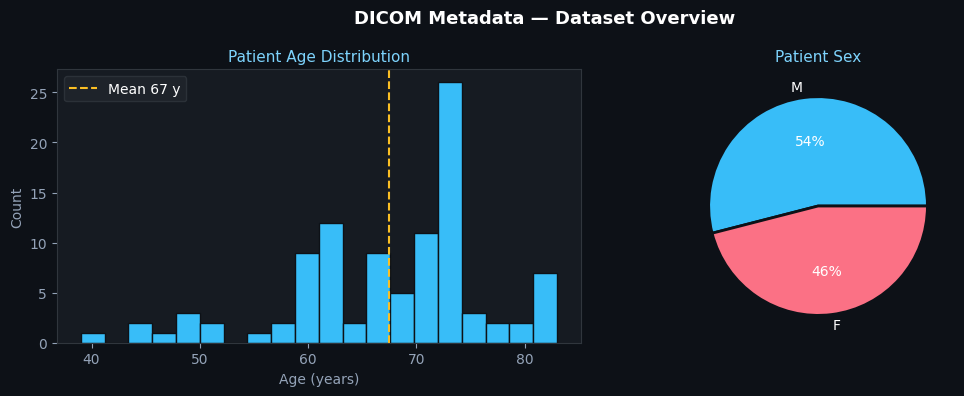

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(BG)
fig.suptitle('DICOM Metadata — Dataset Overview', color='white',
             fontsize=13, fontweight='bold')

ages = pd.to_numeric(meta_df.get('Age'), errors='coerce').dropna()
if len(ages):
    axes[0].hist(ages, bins=20, color=BLUE, edgecolor=BG)
    axes[0].axvline(ages.mean(), color=YELLOW, lw=1.5, ls='--',
                    label=f'Mean {ages.mean():.0f} y')
    axes[0].legend(labelcolor='white', facecolor='#21262d', edgecolor=BORDER)
else:
    axes[0].text(0.5, 0.5, 'Age not available', ha='center',
                 va='center', color=LABEL, transform=axes[0].transAxes)
style_ax(axes[0], 'Patient Age Distribution', 'Age (years)')


if 'PatientSex' in meta_df.columns:
    counts = meta_df['PatientSex'].fillna('Unknown').value_counts()
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.0f%%',
                colors=[BLUE, PINK, YELLOW][:len(counts)],
                textprops={'color': 'white'},
                wedgeprops={'edgecolor': BG, 'linewidth': 2})
style_ax(axes[1], 'Patient Sex', '', '')

plt.tight_layout()
plt.show()


---
## DICOM vs JPEG/PNG — Why Format Matters

| Feature | DICOM `.dcm` | JPEG / PNG |
|---|---|---|
| **Bit depth** | 12–16 bit (up to 65 536 gray levels) | 8 bit (256 levels) |
| **Pixel values** | Hounsfield Units — absolute tissue density | sRGB display values |
| **Metadata** | Full clinical record embedded in every file | Minimal EXIF only |
| **Compression** | Lossless or uncompressed | JPEG is lossy |
| **Multi-frame** | One file = entire CT/MRI series | One file per image |
| **Standard** | ISO 12052 — used by all medical equipment | General web format |

---
## HU Histogram: 16-bit vs Simulated 8-bit

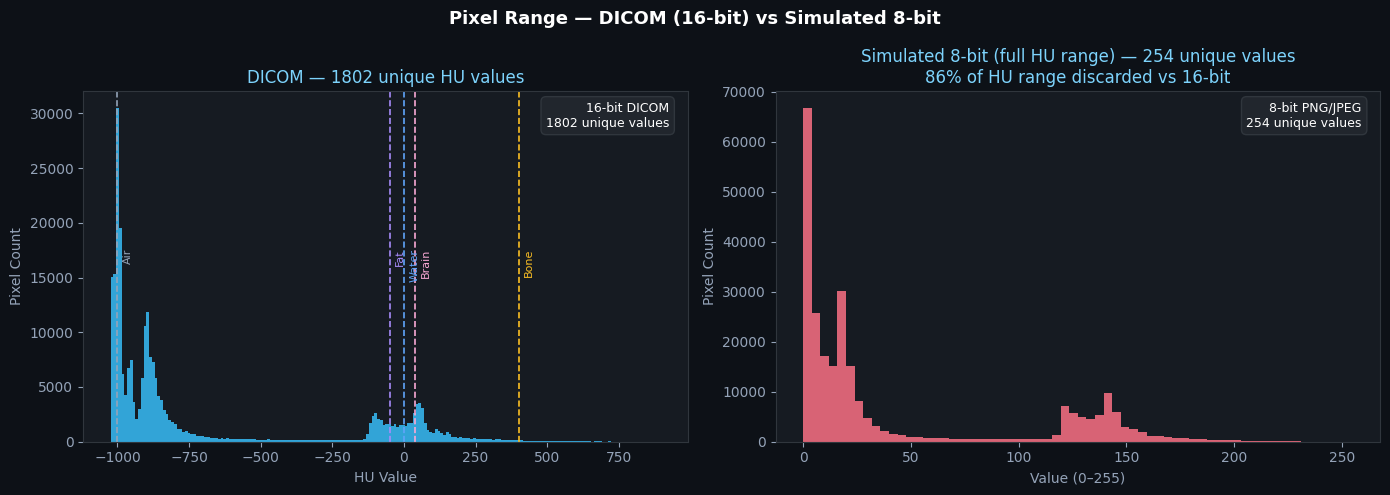

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Pixel Range — DICOM (16-bit) vs Simulated 8-bit',
             color='white', fontsize=13, fontweight='bold')

HU_REF = [(-1000,'Air','#94a3b8'),(-50,'Fat','#a78bfa'),
           (0,'Water','#60a5fa'),(40,'Brain','#f9a8d4'),(400,'Bone',YELLOW)]

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=LABEL)
    for s in ax.spines.values(): s.set_edgecolor(BORDER)

# Left — full 16-bit DICOM histogram
flat = hu_sample.flatten()
axes[0].hist(flat, bins=200, color=BLUE, edgecolor='none', alpha=0.85)
ymax = axes[0].get_ylim()[1]
for hv, lab, col in HU_REF:
    if flat.min() <= hv <= flat.max():
        axes[0].axvline(hv, color=col, lw=1.2, ls='--')
        axes[0].text(hv+20, ymax*0.55, lab, color=col, fontsize=8, rotation=90, va='top')
axes[0].set_title(f'DICOM — {len(np.unique(flat))} unique HU values', color=TITLE)
axes[0].set_xlabel('HU Value', color=LABEL)
axes[0].set_ylabel('Pixel Count', color=LABEL)

# Right — 8-bit simulation using the FULL HU range so no clipping spike
hu_min, hu_max = float(hu_sample.min()), float(hu_sample.max())
bw8  = apply_window(hu_sample, wc=(hu_max + hu_min) / 2, ww=(hu_max - hu_min))
pct  = (1 - len(np.unique(bw8)) / len(np.unique(flat))) * 100
axes[1].hist(bw8.flatten(), bins=64, color=PINK, edgecolor='none', alpha=0.85)
axes[1].set_title(
    f'Simulated 8-bit (full HU range) — {len(np.unique(bw8))} unique values\n'
    f'{pct:.0f}% of HU range discarded vs 16-bit', color=TITLE)
axes[1].set_xlabel('Value (0–255)', color=LABEL)
axes[1].set_ylabel('Pixel Count', color=LABEL)

for ax, txt in [
    (axes[0], f'16-bit DICOM\n{len(np.unique(flat))} unique values'),
    (axes[1], f'8-bit PNG/JPEG\n{len(np.unique(bw8))} unique values'),
]:
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, fontsize=9,
            va='top', ha='right', color='white',
            bbox=dict(boxstyle='round,pad=0.4', fc='#21262d', ec=BORDER))

plt.tight_layout()
plt.show()


---
## Tissue Segmentation by Hounsfield Unit

Each class is defined by a clinically established HU range:

| Tissue | HU range | Colour |
|---|---|---|
| Air | < −950 | Black |
| Lung | −950 → −500 | Dark grey |
| Fat | −500 → −100 | Brown |
| Soft Tissue | −100 → 200 | Salmon |
| Blood / Contrast | 200 → 300 | Red |
| Bone | > 300 | White |

In [10]:
# ── Run segmentation on the sample slice ─────────────────────────────────────
label_map, rgb_map = segment_tissues(hu0)
stats_tbl          = tissue_stats(hu0, label_map, pixel_area_mm2=px_area)

print('Per-class statistics:')
print(stats_tbl.to_string(index=False))


Per-class statistics:
        Tissue  Pixels     %  Mean HU  Std HU  Area cm²
           Air  103177 39.36   -995.6    18.8    629.74
          Lung   92642 35.34   -854.9    81.9    565.44
           Fat   12187  4.65   -221.7   129.7     74.38
   Soft Tissue   46963 17.91     23.2    73.7    286.64
Blood/Contrast    3080  1.17    244.9    28.9     18.80
          Bone    4095  1.56    440.3   117.1     24.99


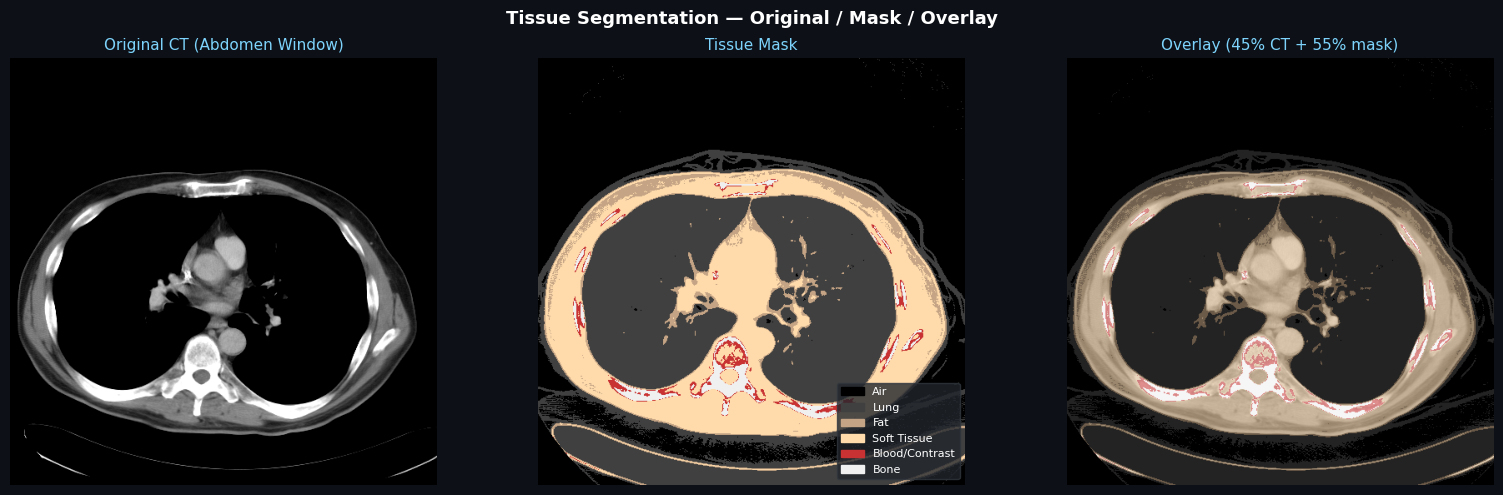

In [11]:
# ── Figure A: Original | Mask | Overlay ──────────────────────────────────────
abdomen_win = apply_window(hu0, 60, 400)
ct_rgb      = np.stack([abdomen_win]*3, axis=-1)
overlay     = (ct_rgb * 0.45 + rgb_map * 0.55).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Tissue Segmentation — Original / Mask / Overlay',
             color='white', fontsize=13, fontweight='bold')

for ax, img, cmap, title in zip(
    axes,
    [abdomen_win, rgb_map, overlay],
    ['gray', None, None],
    ['Original CT (Abdomen Window)', 'Tissue Mask', 'Overlay (45% CT + 55% mask)']
):
    ax.set_facecolor(PANEL)
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, color=TITLE, fontsize=11)
    ax.axis('off')

patches = [mpatches.Patch(color=np.array(c)/255, label=name)
           for name, *_, c in TISSUES]
axes[1].legend(handles=patches, loc='lower right', fontsize=8,
               labelcolor='white', facecolor='#21262d', edgecolor=BORDER)
plt.tight_layout()
plt.show()


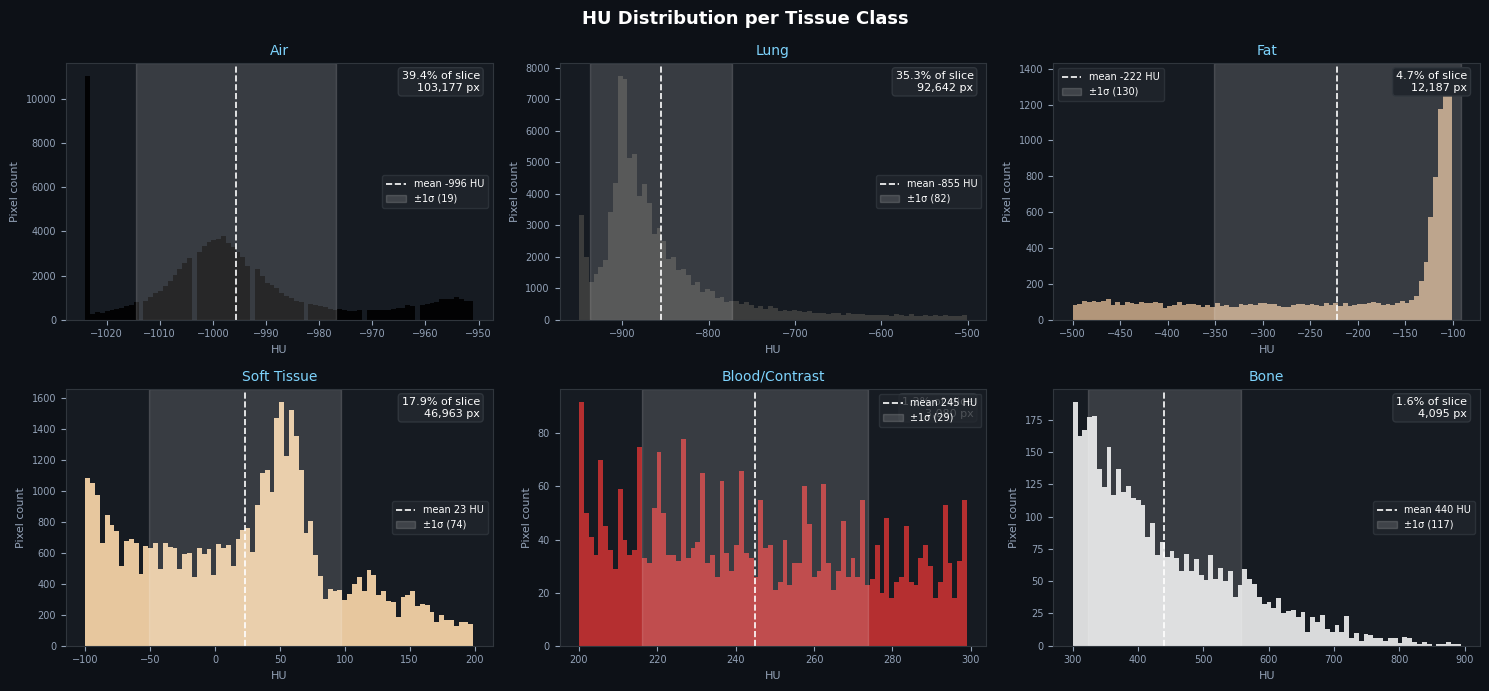

In [12]:
# ── Figure B: HU distribution per tissue class ───────────────────────────────
present = [(i, name, col)
           for i, (name, lo, hi, col) in enumerate(TISSUES)
           if (label_map == i).sum() > 0]

n_t   = len(present)
ncols = 3
nrows = int(np.ceil(n_t / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3.5))
fig.patch.set_facecolor(BG)
fig.suptitle('HU Distribution per Tissue Class',
             color='white', fontsize=13, fontweight='bold')

for ax, (i, name, col) in zip(axes.flat, present):
    ax.set_facecolor(PANEL)
    vals = hu0[label_map == i]
    ax.hist(vals, bins=80, color=np.array(col)/255, edgecolor='none', alpha=0.9)
    mean_v, std_v = vals.mean(), vals.std()
    ax.axvline(mean_v, color='white', lw=1.2, ls='--', label=f'mean {mean_v:.0f} HU')
    ax.axvspan(mean_v-std_v, mean_v+std_v, alpha=0.15, color='white',
               label=f'±1σ ({std_v:.0f})')
    ax.set_title(name, color=TITLE, fontsize=10)
    ax.set_xlabel('HU', color=LABEL, fontsize=8)
    ax.set_ylabel('Pixel count', color=LABEL, fontsize=8)
    ax.tick_params(colors=LABEL, labelsize=7)
    ax.legend(fontsize=7, labelcolor='white', facecolor='#21262d', edgecolor=BORDER)
    for s in ax.spines.values(): s.set_edgecolor(BORDER)
    row = stats_tbl[stats_tbl.Tissue == name].iloc[0]
    ax.text(0.97, 0.97, f"{row['%']:.1f}% of slice\n{row['Pixels']:,} px",
            transform=ax.transAxes, fontsize=8, va='top', ha='right', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#21262d', ec=BORDER))

for ax in axes.flat[n_t:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


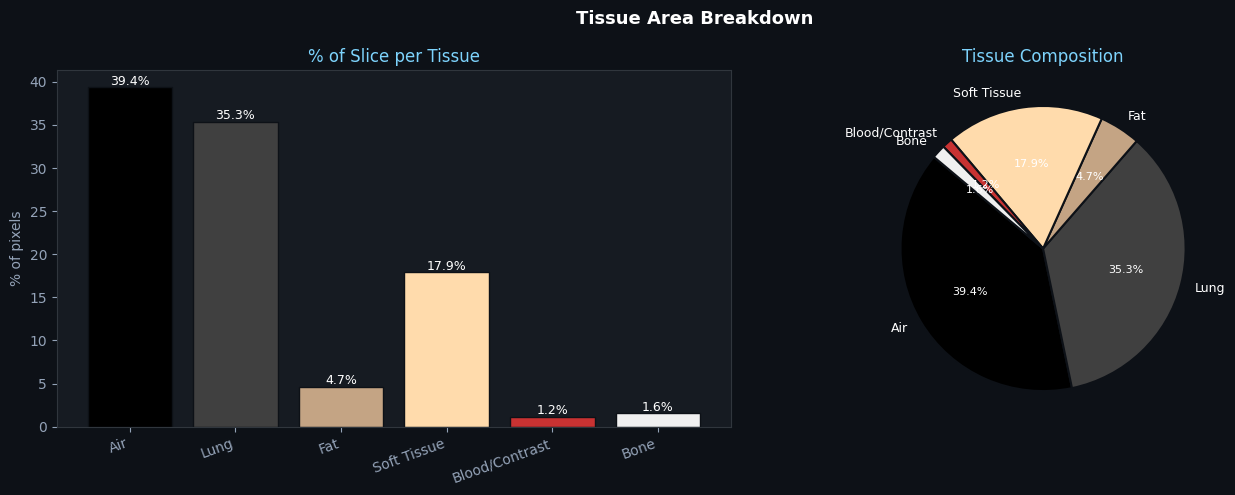


Full statistics table:
        Tissue  Pixels     %  Mean HU  Std HU  Area cm²
           Air  103177 39.36   -995.6    18.8    629.74
          Lung   92642 35.34   -854.9    81.9    565.44
           Fat   12187  4.65   -221.7   129.7     74.38
   Soft Tissue   46963 17.91     23.2    73.7    286.64
Blood/Contrast    3080  1.17    244.9    28.9     18.80
          Bone    4095  1.56    440.3   117.1     24.99


In [13]:
# ── Figure C: Area breakdown bar + pie ───────────────────────────────────────
df_plot  = stats_tbl[stats_tbl['Pixels'] > 0].copy()
t_lookup = {name: col for name, lo, hi, col in TISSUES}
colours  = [np.array(t_lookup[n])/255 for n in df_plot['Tissue']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Tissue Area Breakdown', color='white', fontsize=13, fontweight='bold')

ax = axes[0]
ax.set_facecolor(PANEL)
bars = ax.bar(df_plot['Tissue'], df_plot['%'], color=colours, edgecolor=BG)
for bar, pct in zip(bars, df_plot['%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', color='white', fontsize=9)
ax.set_title('% of Slice per Tissue', color=TITLE)
ax.set_ylabel('% of pixels', color=LABEL)
ax.tick_params(colors=LABEL)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', color=LABEL)
for s in ax.spines.values(): s.set_edgecolor(BORDER)

ax2 = axes[1]
ax2.set_facecolor(PANEL)
wedges, texts, autotexts = ax2.pie(
    df_plot['%'], labels=df_plot['Tissue'], autopct='%1.1f%%',
    colors=colours, textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': BG, 'linewidth': 1.5}, startangle=140)
for t in autotexts: t.set_fontsize(8)
ax2.set_title('Tissue Composition', color=TITLE)

plt.tight_layout()
plt.show()

print('\nFull statistics table:')
print(stats_tbl.to_string(index=False))


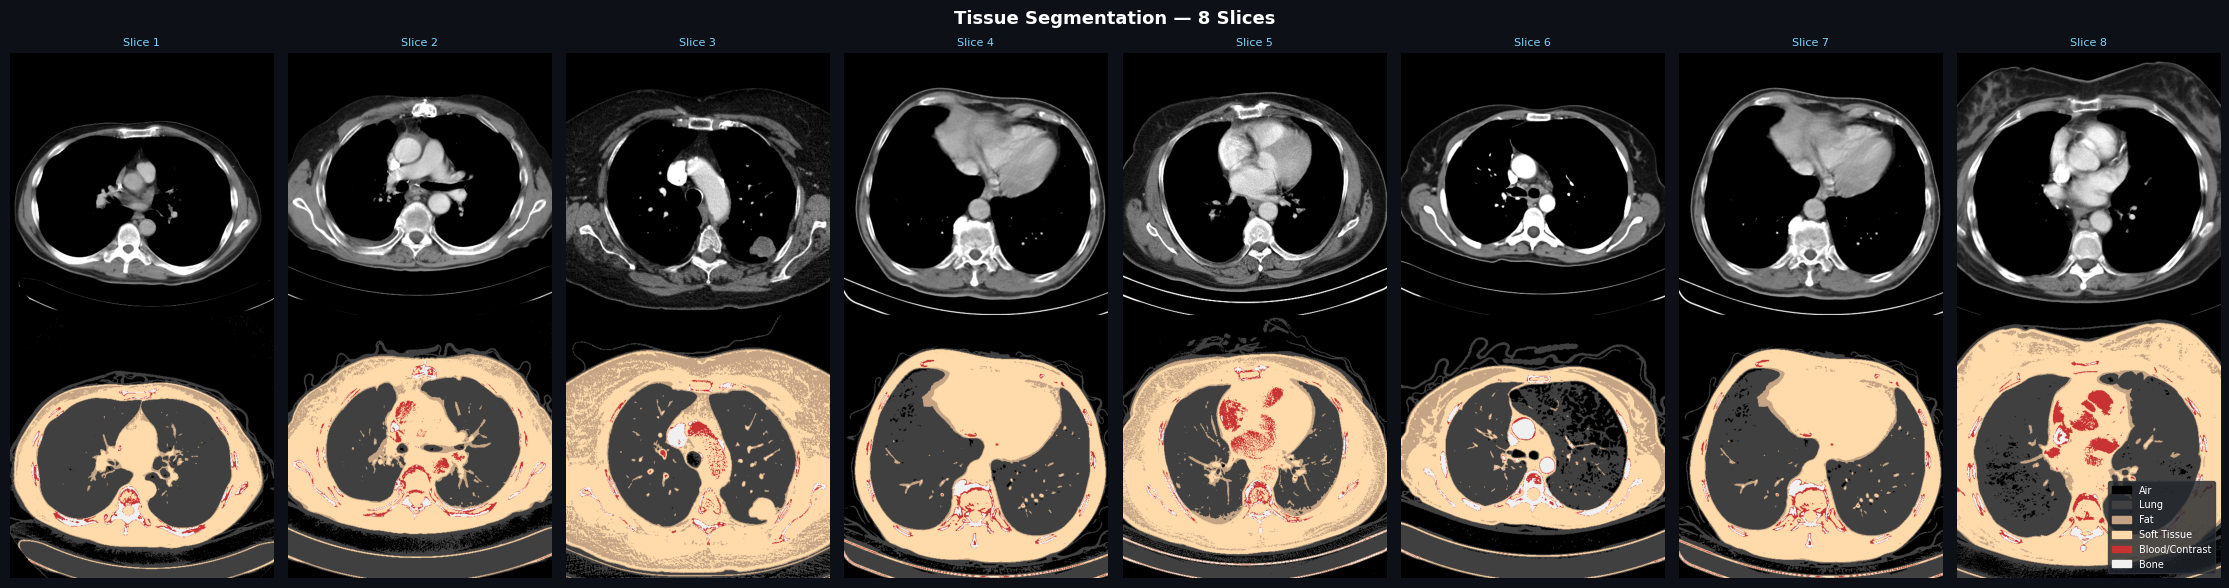

In [14]:
# ── Figure D: Segmentation across multiple slices ────────────────────────────
n_show = min(8, len(dcm_files))
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.8, 6))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Tissue Segmentation — {n_show} Slices',
             color='white', fontsize=13, fontweight='bold')

for col, path in enumerate(dcm_files[:n_show]):
    d  = dcmread(path)
    h  = to_hu(d)
    lm, rm = segment_tissues(h)
    win    = apply_window(h, 60, 400)
    axes[0, col].set_facecolor(PANEL)
    axes[0, col].imshow(win, cmap='gray')
    axes[0, col].set_title(f'Slice {col+1}', color=TITLE, fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].set_facecolor(PANEL)
    axes[1, col].imshow(rm)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('CT Image',    color=LABEL, fontsize=9)
axes[1, 0].set_ylabel('Tissue Mask', color=LABEL, fontsize=9)
patches = [mpatches.Patch(color=np.array(c)/255, label=n) for n, *_, c in TISSUES]
axes[1, -1].legend(handles=patches, loc='lower right', fontsize=7,
                   labelcolor='white', facecolor='#21262d', edgecolor=BORDER)
plt.tight_layout()
plt.show()


---
## Full Analysis Dashboard

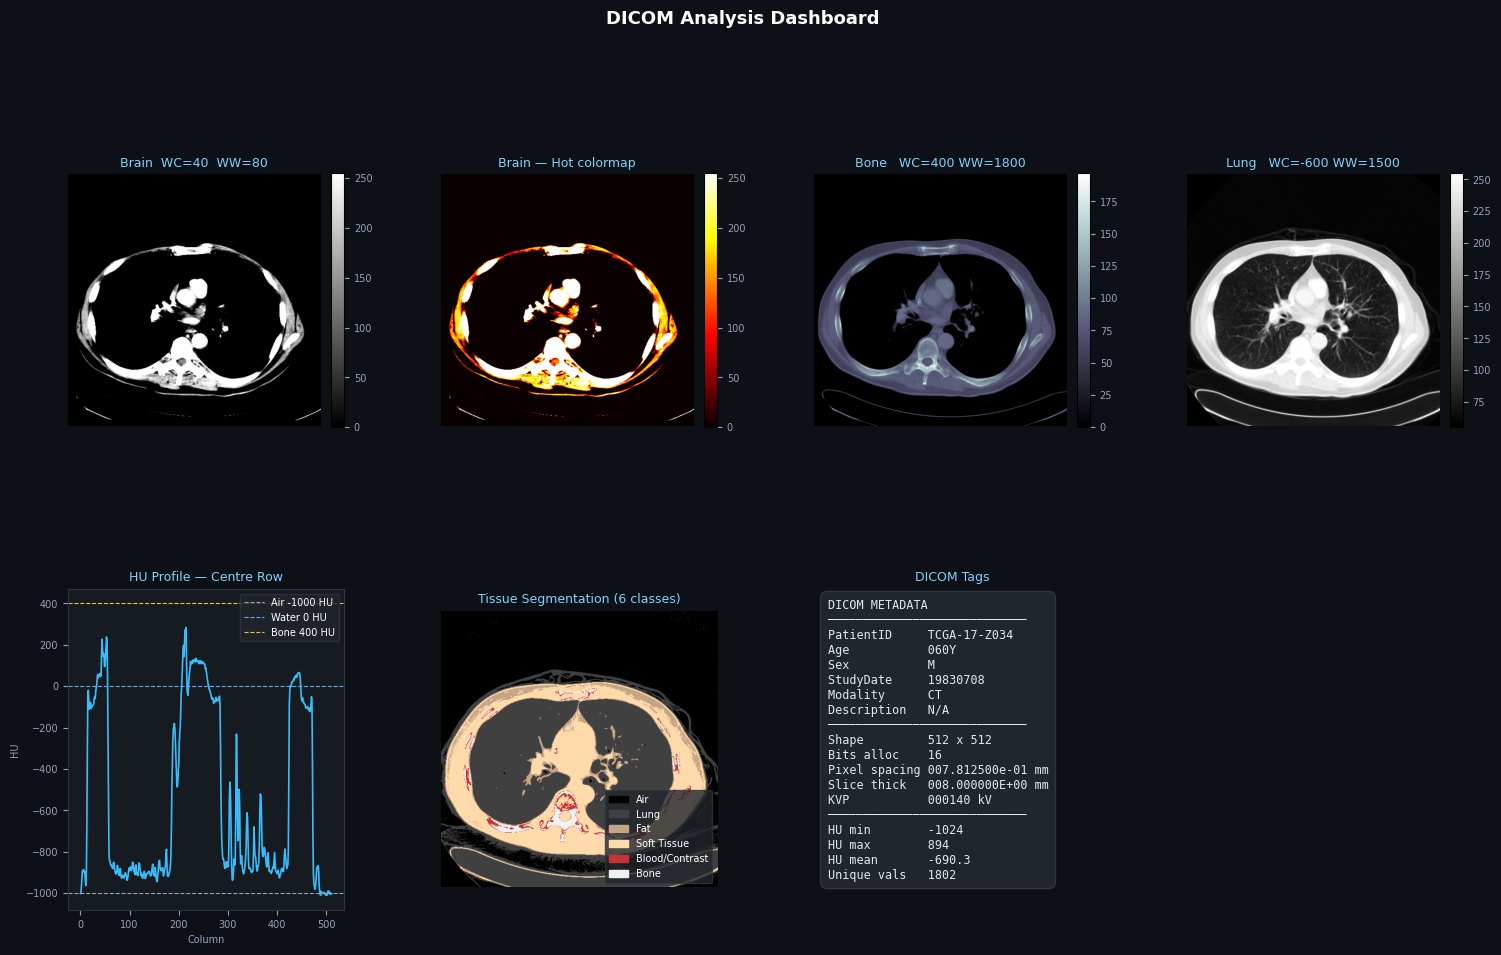

In [15]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

for spec, img, cmap, title in [
    (gs[0,0], apply_window(hu0,   40,   80), 'gray',      'Brain  WC=40  WW=80'),
    (gs[0,1], apply_window(hu0,   40,   80), 'hot',       'Brain — Hot colormap'),
    (gs[0,2], apply_window(hu0,  400, 1800), 'bone',      'Bone   WC=400 WW=1800'),
    (gs[0,3], apply_window(hu0, -600, 1500), 'gist_gray', 'Lung   WC=-600 WW=1500'),
]:
    ax = fig.add_subplot(spec)
    ax.set_facecolor(PANEL)
    im = ax.imshow(img, cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=LABEL, labelsize=7)
    ax.set_title(title, color=TITLE, fontsize=9, pad=5)
    ax.axis('off')


# HU profile
ax_p = fig.add_subplot(gs[1,0])
ax_p.set_facecolor(PANEL)
mid = hu0[hu0.shape[0]//2, :]
ax_p.plot(mid, color=BLUE, lw=1.2)
for hv, lab, col in [(-1000,'Air','#94a3b8'),(0,'Water','#60a5fa'),(400,'Bone',YELLOW)]:
    ax_p.axhline(hv, color=col, lw=0.8, ls='--', label=f'{lab} {hv} HU')
ax_p.set_title('HU Profile — Centre Row', color=TITLE, fontsize=9)
ax_p.set_xlabel('Column', color=LABEL, fontsize=7)
ax_p.set_ylabel('HU', color=LABEL, fontsize=7)
ax_p.tick_params(colors=LABEL, labelsize=7)
ax_p.legend(fontsize=7, labelcolor='white', facecolor='#21262d', edgecolor=BORDER)
for s in ax_p.spines.values(): s.set_edgecolor(BORDER)

# Tissue segmentation
ax_s = fig.add_subplot(gs[1,1])
ax_s.set_facecolor(PANEL)
_, rgb_dash = segment_tissues(hu0)
ax_s.imshow(rgb_dash)
ax_s.legend(handles=[mpatches.Patch(color=np.array(c)/255, label=n) for n, lo, hi, c in TISSUES],
            loc='lower right', fontsize=7, labelcolor='white',
            facecolor='#21262d', edgecolor=BORDER)
ax_s.set_title('Tissue Segmentation (6 classes)', color=TITLE, fontsize=9)
ax_s.axis('off')

# Metadata panel
ax_i = fig.add_subplot(gs[1,2])
ax_i.set_facecolor(PANEL)
ax_i.axis('off')
ps_val = tag(ds0, 'PixelSpacing', ['?', '?'])
info = (
    f"DICOM METADATA\n{'─'*28}\n"
    f"PatientID     {tag(ds0,'PatientID')}\n"
    f"Age           {tag(ds0,'PatientAge')}\n"
    f"Sex           {tag(ds0,'PatientSex')}\n"
    f"StudyDate     {tag(ds0,'StudyDate')}\n"
    f"Modality      {tag(ds0,'Modality')}\n"
    f"Description   {str(tag(ds0,'StudyDescription'))[:20]}\n"
    f"{'─'*28}\n"
    f"Shape         {hu0.shape[0]} x {hu0.shape[1]}\n"
    f"Bits alloc    {tag(ds0,'BitsAllocated')}\n"
    f"Pixel spacing {ps_val[0]} mm\n"
    f"Slice thick   {tag(ds0,'SliceThickness')} mm\n"
    f"KVP           {tag(ds0,'KVP')} kV\n"
    f"{'─'*28}\n"
    f"HU min        {hu0.min():.0f}\n"
    f"HU max        {hu0.max():.0f}\n"
    f"HU mean       {hu0.mean():.1f}\n"
    f"Unique vals   {len(np.unique(hu0))}"
)
ax_i.text(0.05, 0.97, info, transform=ax_i.transAxes,
          fontsize=8.5, va='top', color='#e2e8f0', family='monospace',
          bbox=dict(boxstyle='round,pad=0.6', fc='#21262d', ec=BORDER))
ax_i.set_title('DICOM Tags', color=TITLE, fontsize=9)

fig.suptitle('DICOM Analysis Dashboard', color='white',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()


---
## Browse 12 Slices

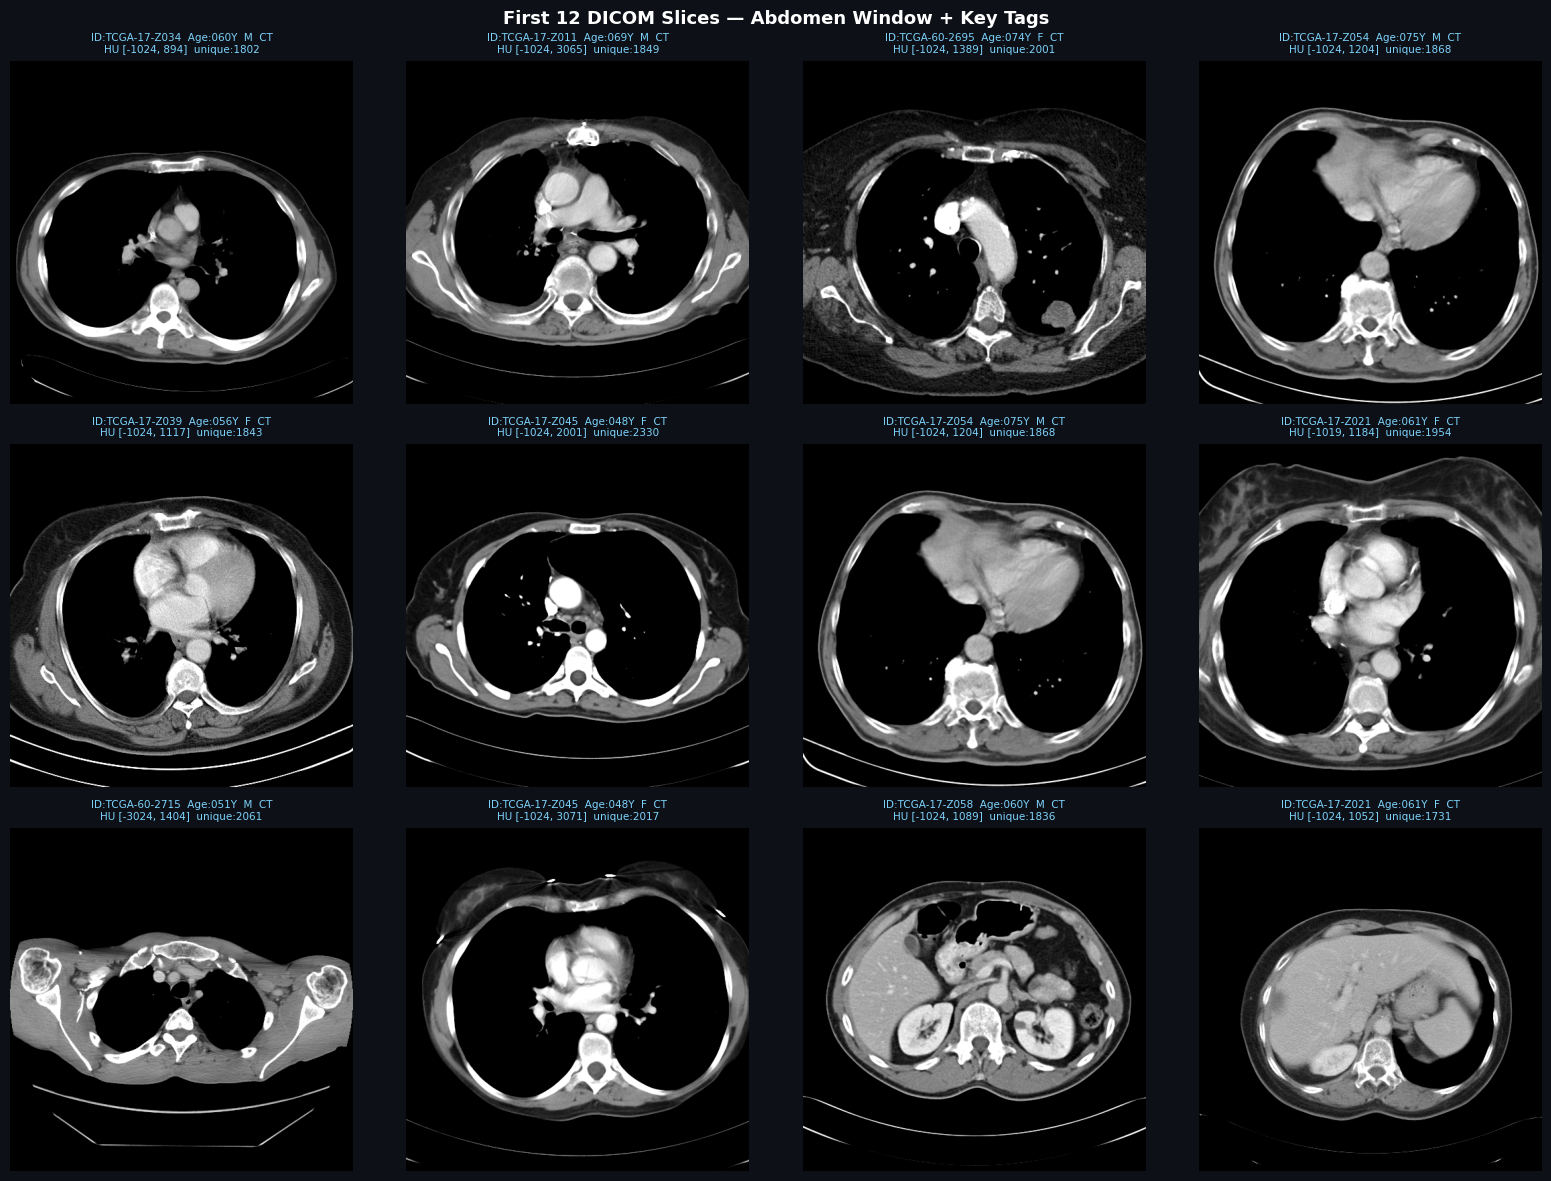

In [16]:
n_show = min(12, len(dcm_files))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.patch.set_facecolor(BG)
fig.suptitle(f'First {n_show} DICOM Slices — Abdomen Window + Key Tags',
             color='white', fontsize=13, fontweight='bold')

for ax, path in zip(axes.flat, dcm_files[:n_show]):
    d = dcmread(path)
    h = to_hu(d)
    ax.set_facecolor(PANEL)
    ax.imshow(apply_window(h, 60, 400), cmap='gray')
    ax.set_title(
        f"ID:{tag(d,'PatientID','?')}  Age:{tag(d,'PatientAge','?')}  "        f"{tag(d,'PatientSex','?')}  {tag(d,'Modality','?')}\n"        f"HU [{h.min():.0f}, {h.max():.0f}]  unique:{len(np.unique(h))}",
        color=TITLE, fontsize=7.5)
    ax.axis('off')

for ax in axes.flat[n_show:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


---
## Dataset-Wide Pixel Statistics

Computing pixel statistics for all 100 files…
✓ Done — 100 slices


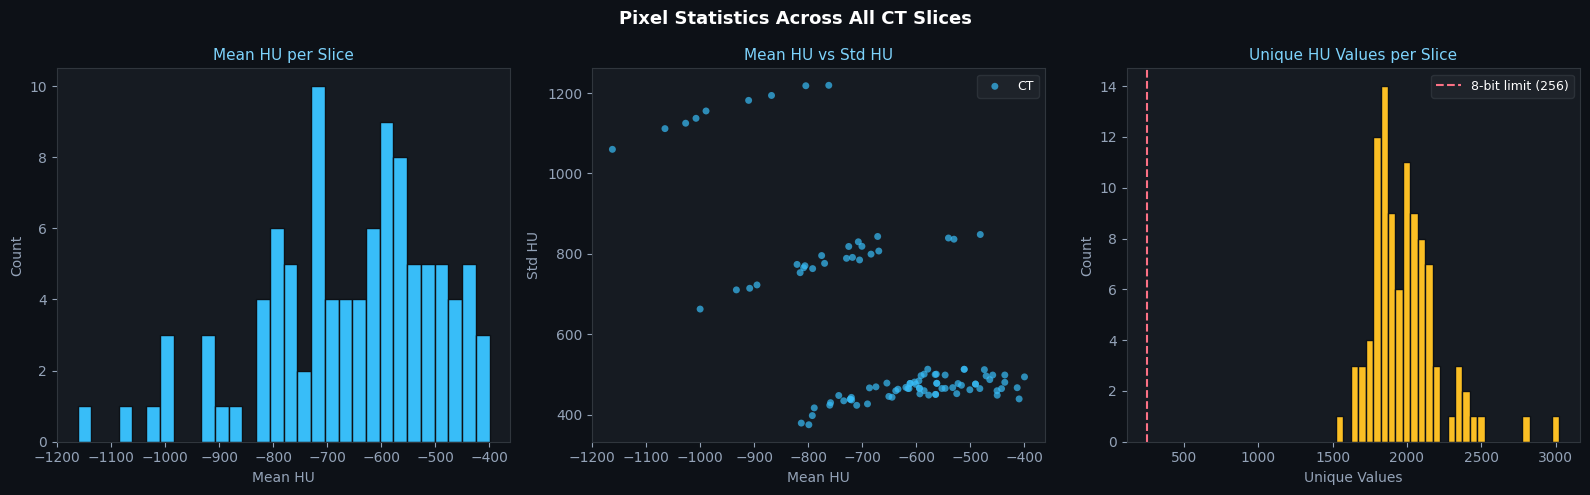

In [17]:
print(f'Computing pixel statistics for all {len(dcm_files)} files…')
stats = []
for path in dcm_files:
    d = dcmread(path)
    h = to_hu(d)
    stats.append({
        'file'    : os.path.basename(path),
        'mean_hu' : float(h.mean()),
        'std_hu'  : float(h.std()),
        'min_hu'  : float(h.min()),
        'max_hu'  : float(h.max()),
        'unique'  : int(len(np.unique(h))),
        'Age'     : parse_age(getattr(d, 'PatientAge', None)),
        'Sex'     : getattr(d, 'PatientSex', '?'),
        'Modality': getattr(d, 'Modality',   'CT'),
    })
stats_df = pd.DataFrame(stats)
print(f'✓ Done — {len(stats_df)} slices')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Pixel Statistics Across All CT Slices',
             color='white', fontsize=13, fontweight='bold')

axes[0].hist(stats_df['mean_hu'], bins=30, color=BLUE, edgecolor=BG)
style_ax(axes[0], 'Mean HU per Slice', 'Mean HU')

pal = dict(zip(stats_df['Modality'].unique(), [BLUE, GREEN, PINK, YELLOW]))
for mod, grp in stats_df.groupby('Modality'):
    axes[1].scatter(grp['mean_hu'], grp['std_hu'],
                    c=pal.get(mod, BLUE), alpha=0.7, s=25, edgecolors='none', label=mod)
axes[1].legend(labelcolor='white', facecolor='#21262d', edgecolor=BORDER, fontsize=9)
style_ax(axes[1], 'Mean HU vs Std HU', 'Mean HU', 'Std HU')

axes[2].hist(stats_df['unique'], bins=30, color=YELLOW, edgecolor=BG)
axes[2].axvline(256, color=PINK, lw=1.5, ls='--', label='8-bit limit (256)')
axes[2].legend(labelcolor='white', facecolor='#21262d', edgecolor=BORDER, fontsize=9)
style_ax(axes[2], 'Unique HU Values per Slice', 'Unique Values')

plt.tight_layout()
plt.show()


---
## Export — PNG or Lossless NPY

In [18]:
def export_dicom_files(file_list, out_dir, fmt='png', wc=60, ww=400, max_files=None):
    """
    Export DICOM files to PNG (display) or NPY (lossless HU).
    fmt='png' — 8-bit windowed image  (display / annotation)
    fmt='npy' — float32 HU array      (lossless, recommended for ML)
    """
    os.makedirs(out_dir, exist_ok=True)
    targets = file_list[:max_files] if max_files else file_list
    for path in targets:
        stem = os.path.splitext(os.path.basename(path))[0]
        try:
            d = dcmread(path)
            h = to_hu(d)
            if fmt == 'png':
                Image.fromarray(apply_window(h, wc, ww)).save(
                    os.path.join(out_dir, stem + '.png'))
            elif fmt == 'npy':
                np.save(os.path.join(out_dir, stem + '.npy'), h.astype(np.float32))
        except Exception as e:
            print(f'  skip {stem}: {e}')
    n = len(glob.glob(os.path.join(out_dir, f'*.{fmt}')))
    print(f'✓ Exported {n} {fmt.upper()} files → {out_dir}')

# Uncomment to run:
# export_dicom_files(dcm_files, './exports_png', fmt='png')
# export_dicom_files(dcm_files, './exports_npy', fmt='npy')
print('export_dicom_files() ready.')


export_dicom_files() ready.


---
## Summary

| Cell | What it does |
|---|---|
| 1 | Imports |
| 2 | **All helper functions** — `to_hu`, `apply_window`, `TISSUES`, `segment_tissues`, `tissue_stats`, `parse_age`, `style_ax`, `tag` |
| 3 | Configure path to dataset |
| 4 | Load sample file → `ds0`, `hu0`, `hu_sample`, `px_area` |
| 5 | Print all DICOM tags |
| 6 | Batch-read metadata → `meta_df` |
| 7 | Numeric + categorical metadata summary |
| 8 | Age / Modality / Sex plots |
| 9 | DICOM vs JPEG/PNG comparison table |
| 10 | Clinical windowing — 6 presets |
| 11 | HU histogram: 16-bit vs simulated 8-bit |
| 12 | **Tissue segmentation** — mask, overlay, per-tissue histograms, area breakdown, multi-slice grid |
| 13 | Full analysis dashboard |
| 14 | Browse 12 slices with metadata titles |
| 15 | Dataset-wide pixel statistics |
| 16 | Export PNG / NPY |